In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# =========================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam


2026-02-19 05:18:54.454975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771478334.683913      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771478334.750920      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771478335.296599      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771478335.296653      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771478335.296656      55 computation_placer.cc:177] computation placer alr

In [3]:
# =========================================================
# CELL 2: DEFINE CONFIGURATION PARAMETERS
# =========================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 8

DATASET_PATH = "/kaggle/input/datasets/vencerlanz09/agricultural-pests-image-dataset"


In [4]:
# =========================================================
# CELL 3: DATASET LOADING
# =========================================================

images = []
labels = []

class_names = sorted(os.listdir(DATASET_PATH))

for class_idx, class_name in enumerate(class_names):

    class_folder = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_folder):
        for img_name in os.listdir(class_folder):

            img_path = os.path.join(class_folder, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
                images.append(img)
                labels.append(class_idx)

images = np.array(images)
labels = np.array(labels)

print("Dataset Loaded Successfully")
print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)


Dataset Loaded Successfully
Images Shape: (5494, 224, 224, 3)
Labels Shape: (5494,)


In [5]:
# =========================================================
# CELL 4: APPLY CLAHE IMAGE ENHANCEMENT
# =========================================================

def apply_clahe(image):

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

processed_images = np.array([apply_clahe(img) for img in images])
processed_images = processed_images / 255.0

print("CLAHE Processing Completed")


CLAHE Processing Completed


In [6]:
# =========================================================
# CELL 5: TRAIN-VALIDATION SPLIT
# =========================================================

X_train, X_val, y_train, y_val = train_test_split(
    processed_images,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Validation Samples:", X_val.shape[0])


Training Samples: 4395
Validation Samples: 1099


In [10]:
# =========================================================
# CELL 6: PATCH EXTRACTION LAYER
# =========================================================

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)


In [11]:
# =========================================================
# CELL 7: BUILD VISION TRANSFORMER MODEL
# =========================================================

inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

patches = Patches(PATCH_SIZE)(inputs)
encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

for _ in range(TRANSFORMER_LAYERS):

    x1 = layers.LayerNormalization()(encoded_patches)
    attention_output = layers.MultiHeadAttention(
        num_heads=NUM_HEADS, key_dim=PROJECTION_DIM
    )(x1, x1)

    x2 = layers.Add()([attention_output, encoded_patches])

    x3 = layers.LayerNormalization()(x2)
    x3 = layers.Dense(PROJECTION_DIM * 2, activation="gelu")(x3)
    x3 = layers.Dense(PROJECTION_DIM)(x3)

    encoded_patches = layers.Add()([x3, x2])

representation = layers.LayerNormalization()(encoded_patches)
representation = layers.GlobalAveragePooling1D()(representation)

representation = layers.Dropout(0.3)(representation)

outputs = layers.Dense(len(class_names), activation="softmax")(representation)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


2026-02-19 05:21:38.684938: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 64)   │     61,760 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 64)   │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ dense_2[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 64)   │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 196, 64)   │          0 │ dense_4[0][0],    │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 728,268 (2.78 MB)

 Trainable params: 728,268 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# =========================================================
# CELL 8: TRAIN VISION TRANSFORMER
# =========================================================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.0881 - loss: 2.8953 - val_accuracy: 0.1065 - val_loss: 2.4786
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.0904 - loss: 2.5729 - val_accuracy: 0.1083 - val_loss: 2.4553
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.1146 - loss: 2.4693 - val_accuracy: 0.1283 - val_loss: 2.4000
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.1314 - loss: 2.4181 - val_accuracy: 0.1319 - val_loss: 2.3949
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.1583 - loss: 2.3700 - val_accuracy: 0.1756 - val_loss: 2.3526
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.1868 - loss: 2.3264 - val_accuracy: 0.1975 - val_loss: 2.3103
Epoch 7/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.2352 - loss: 2.2484 - val_accuracy: 0.2648 - val_loss: 2.1616
Epoch 8/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.2695 - loss: 2.1635 - val_accu

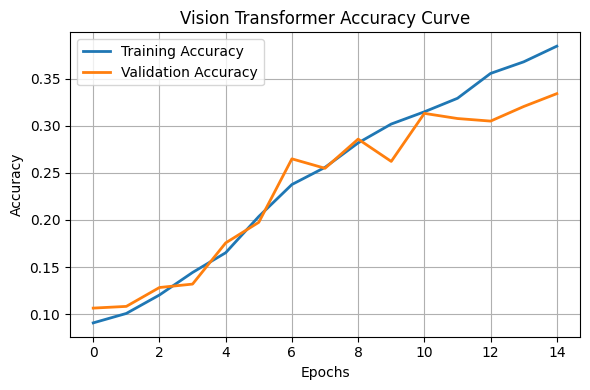

In [13]:
# =========================================================
# CELL 9: ACCURACY CURVE
# =========================================================

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linewidth=2, label='Validation Accuracy')

plt.title("Vision Transformer Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/vit_accuracy_curve.png", dpi=300)
plt.show()


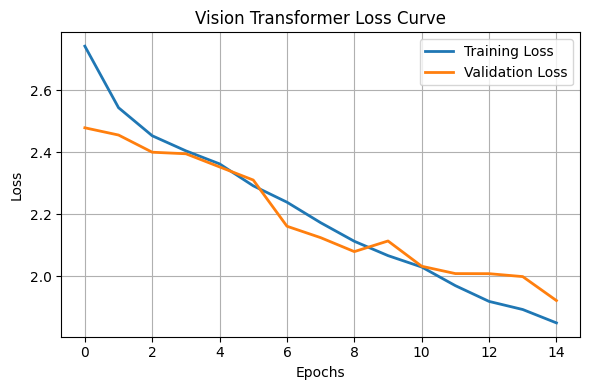

In [14]:
# =========================================================
# CELL 10: LOSS CURVE
# =========================================================

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], linewidth=2, label='Validation Loss')

plt.title("Vision Transformer Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/vit_loss_curve.png", dpi=300)
plt.show()


35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 613ms/step


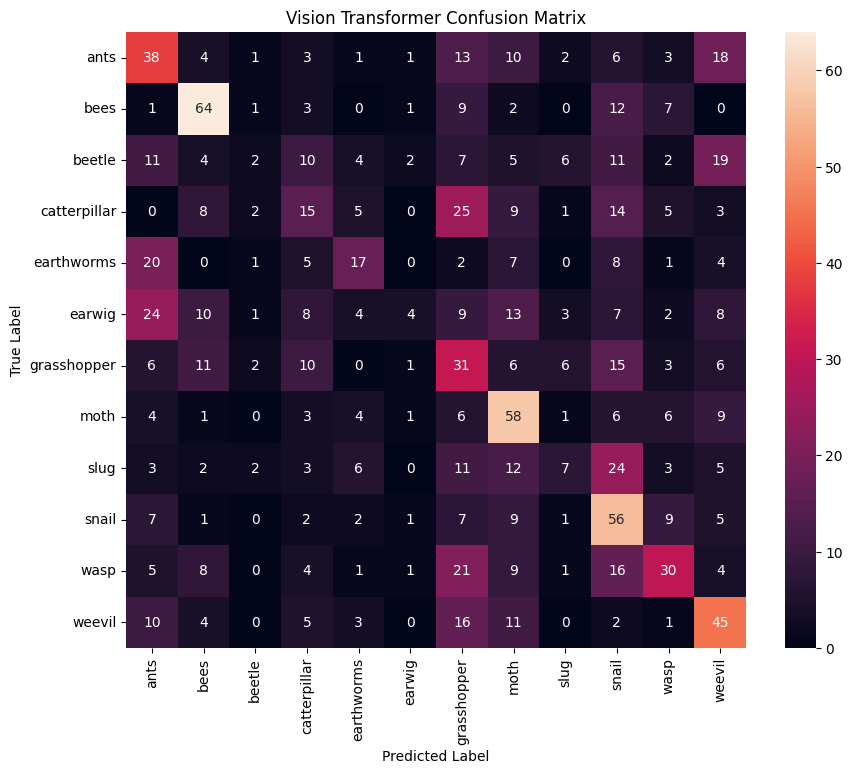

In [15]:
# =========================================================
# CELL 11: CONFUSION MATRIX
# =========================================================

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Vision Transformer Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [16]:
# =========================================================
# CELL 12: CLASSIFICATION REPORT
# =========================================================

print(classification_report(y_val, y_pred_classes, target_names=class_names))


              precision    recall  f1-score   support

        ants       0.29      0.38      0.33       100
        bees       0.55      0.64      0.59       100
      beetle       0.17      0.02      0.04        83
catterpillar       0.21      0.17      0.19        87
  earthworms       0.36      0.26      0.30        65
      earwig       0.33      0.04      0.08        93
 grasshopper       0.20      0.32      0.24        97
        moth       0.38      0.59      0.46        99
        slug       0.25      0.09      0.13        78
       snail       0.32      0.56      0.40       100
        wasp       0.42      0.30      0.35       100
      weevil       0.36      0.46      0.40        97

    accuracy                           0.33      1099
   macro avg       0.32      0.32      0.29      1099
weighted avg       0.32      0.33      0.30      1099

